In [1]:
# importing libs 
from torchvision import datasets 
import torch 
import torch.nn as nn 
import torch.optim as optim
from matplotlib import pyplot as plt 
from torchvision import transforms 
import datetime
from collections import OrderedDict
import numpy as np 

import torch.nn.functional as F  

In [2]:
# downloading CIFAR-10 data using torchvison 
data_path = "data/"
cifar10 = datasets.CIFAR10(data_path, train=True, download=False) 
cifar10_val = datasets.CIFAR10(data_path, train=False, download=False)


In [3]:
cifar10 = datasets.CIFAR10(data_path, train=True, download=False,transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.4915, 0.4823, 0.4468), std=(0.247, 0.2435, 0.2616))])) 
cifar10_val = datasets.CIFAR10(data_path, train=False, download=False,transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.4915, 0.4823, 0.4468), std=(0.247, 0.2435, 0.2616))]))

# building data set 

# filtering the cifar10 data and remap the labels. 
label_map = {0: 0, 2: 1}
class_names = ['airplane','bird']

cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0,2]]
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0,2]]

In [4]:
# Convlution in action 
conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3) 
print(conv)
print(conv.weight.shape, conv.bias.shape)

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
torch.Size([16, 3, 3, 3]) torch.Size([16])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
torch.Size([1, 3, 32, 32]) torch.Size([1, 16, 30, 30])


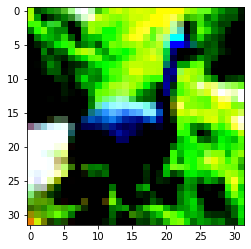

In [5]:
# passing img to conv layer 
img,_ = cifar2[0] 
output = conv(img.unsqueeze(0))

print(img.unsqueeze(0).shape, output.shape)
plt.imshow(img.permute(1,2,0), cmap="gray")

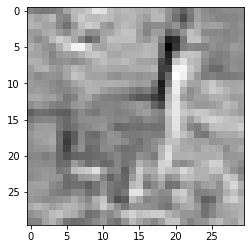

In [6]:
plt.imshow(output[0,0].detach(), cmap="gray")

torch.Size([1, 3, 32, 32]) torch.Size([1, 1, 32, 32])


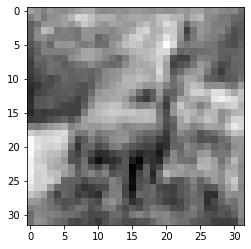

In [7]:
# adding padding to the conv layer 
conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=1) 
output = conv(img.unsqueeze(0)) 
print(img.unsqueeze(0).shape, output.shape)
plt.imshow(output[0,0].detach(), cmap="gray")

In [8]:
# detecting features with convolutions 
# manuallly setting weights by hand 
with torch.no_grad():
    conv.bias.zero_()
    print(conv.bias)

with torch.no_grad():
    conv.weight.fill_(1.0/9.0)
    #conv.weight.one_() # we used this which would result in each pixel in the output being the sum of the pixel in the neighborhood. 
    print(conv.weight)

Parameter containing:
tensor([0.], requires_grad=True)
Parameter containing:
tensor([[[[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]],

         [[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]],

         [[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]]]], requires_grad=True)


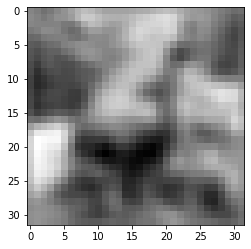

In [9]:
output = conv(img.unsqueeze(0)) 
plt.imshow(output[0,0].detach(), cmap="gray")
plt.show()

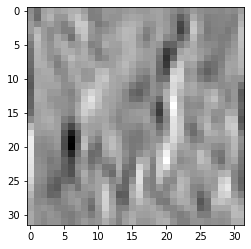

In [10]:
# trying a different approcah in filling the weight 
conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=1)

with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1.0, 0.0, 1.0],
                                    [-1.0, 0.0, 1.0],
                                    [-1.0, 0.0, 1.0]])
    conv.bias.zero_()

output = conv(img.unsqueeze(0))
plt.imshow(output[0,0].detach(), cmap="gray")
plt.show()

In [11]:
# max pooling 
pool = nn.MaxPool2d(2)
output = pool(img.unsqueeze(0)) 
print(img.unsqueeze(0).shape, output.shape)

torch.Size([1, 3, 32, 32]) torch.Size([1, 3, 16, 16])


In [12]:
# putting it all together for the network 
model = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
                        nn.Tanh(), 
                        nn.MaxPool2d(2),
                        nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1),
                        nn.Tanh(),
                        nn.MaxPool2d(2),
                        #....
                        nn.Linear(8*8*8,32),
                        nn.Tanh(),
                        nn.Linear(32,2))

# count of the number of parameters 
numel_list = [p.numel() for p in model.parameters()]
print(sum(numel_list), numel_list)

18090 [432, 16, 1152, 8, 16384, 32, 64, 2]


In [13]:
# Subclassing nn.Module 
class Net(nn.Module):
    def __init__(self):
        super().__init__() 
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1) 
        self.act = nn.Tanh() 
        self.pool_2x2 = nn.MaxPool2d(2) 
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8*8*8,32) 
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.pool_2x2(self.act(self.conv1(x)))
        out = self.pool_2x2(self.act(self.conv2(out))) 
        out = out.view(-1, 8*8*8) # reshaping output to nn.linear 
        out = self.act(self.fc1(out)) 
        out = self.fc2(out)
        
        return out

model = Net()
print(model(img.unsqueeze(0)))

numel_list = [p.numel() for p in model.parameters()]
print(sum(numel_list), numel_list)

tensor([[-0.0688, -0.1285]], grad_fn=<AddmmBackward>)
18090 [432, 16, 1152, 8, 16384, 32, 64, 2]


In [14]:
# Functional API 
# using functional function to create model 

class Net(nn.Module):
    def __init__(self):
        super().__init__() 
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)  
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1) 
        self.fc1 = nn.Linear(8*8*8, 32) 
        self.fc2 = nn.Linear(32, 2) 
    
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2) 
        out = out.view(-1, 8*8*8) 
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out) 
        return out 

model = Net()
print(model(img.unsqueeze(0)))


tensor([[-0.4757, -0.0230]], grad_fn=<AddmmBackward>)


In [15]:
# training model 
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs+1): # we loop over the epochs number from 1 rather than 0 
        loss_train = 0.0 
        for imgs, labels in train_loader: # looping over dataset in batches created by the dataloader 
            output = model(imgs) 
            loss = loss_fn(output, labels) # computing the loss 
            optimizer.zero_grad() # zero_grad 
            loss.backward()  # performing backward to compute the grad of all params from the network
            optimizer.step()  # updating the model 

            loss_train += loss.item() 
        if epoch == 1 or epoch%10 == 0:
            print(f"{datetime.datetime.now()} Epoch {epoch}, Training loss {loss_train/len(train_loader)}")
        
        

In [16]:
# validate model 
def validate(model, train_loader, val_loader):
    accdict = {}
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0 
        total = 0 

        with torch.no_grad():
            for imgs, labels in loader:
                outputs = model(imgs) 
                _, predicted = torch.max(outputs, dim=1) 
                total += labels.shape[0] 
                correct += int((predicted == labels).sum())
        print(f"Accuracy {name}: {round((correct/total),2)}")
        accdict[name] = correct / total
    return accdict



In [17]:
# Training model 

# creating data loader  for training
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)


# creating model 
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1) 
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2) 
    
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2) 
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8) 
        out = torch.tanh(self.fc1(out)) 
        out = self.fc2(out)
        return out 

model = Net() 
learning_rate = 1e-3 
optimizer = optim.SGD(model.parameters(), lr=learning_rate) 
loss_fn = nn.CrossEntropyLoss() 

training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader,)

all_acc_dict = OrderedDict()

# creating data loader  for validation
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
all_acc_dict["basline"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)

2020-08-25 22:11:02.394107 Epoch 1, Training loss 0.6873512325013519
2020-08-25 22:11:21.522009 Epoch 10, Training loss 0.5973257638846233
2020-08-25 22:11:42.014729 Epoch 20, Training loss 0.5118871741234117
2020-08-25 22:12:03.498693 Epoch 30, Training loss 0.47557532730375884
2020-08-25 22:12:21.766457 Epoch 40, Training loss 0.44537575400559004
2020-08-25 22:12:40.372816 Epoch 50, Training loss 0.41483515804740273
2020-08-25 22:12:59.996547 Epoch 60, Training loss 0.3881936335259942
2020-08-25 22:13:18.954510 Epoch 70, Training loss 0.3667507444977001
2020-08-25 22:13:39.163009 Epoch 80, Training loss 0.3534619909752706
2020-08-25 22:13:58.735994 Epoch 90, Training loss 0.3428220918793587
2020-08-25 22:14:19.229639 Epoch 100, Training loss 0.33380378535978356
Accuracy train: 0.85
Accuracy val: 0.84


In [18]:
# saving and loading model
torch.save(model.state_dict(), data_path + "birds_vs_airplanes.pt") # saving model 

loaded_model = Net() # initializing model 
loaded_model.load_state_dict(torch.load(data_path + "birds_vs_airplanes.pt")) # loading model 

<All keys matched successfully>

In [19]:
# Training on GPU 
"""
We use to .to function in the nn.Module to move all params to GPU. 
we use torch.cuda.is_available to check if GPU is available 
"""
device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")


# modifying training_loop function to train on device 
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader, device):
    for epoch in range(1, n_epochs+1):
        loss_train = 0.0 
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)
            labels = labels.to(device=device) 
            outputs = model(imgs) 
            loss = loss_fn(outputs, labels)  

            optimizer.zero_grad()
            loss.backward()
            optimizer.step() 

            loss_train += loss.item()
    
        if epoch == 1 or epoch % 10 == 0:
            print(f"{datetime.datetime.now()} Epoch {epoch}, Training loss {round(loss_train/len(train_loader),4)}")


# creating data loader  for training
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)


model = Net().to(device=device)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)
all_acc_dict["basline_device"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)

Training on device cpu.
2020-08-25 22:14:23.024218 Epoch 1, Training loss 0.6159
2020-08-25 22:14:42.565607 Epoch 10, Training loss 0.3451
2020-08-25 22:15:04.154240 Epoch 20, Training loss 0.3063
2020-08-25 22:15:25.948305 Epoch 30, Training loss 0.2727
2020-08-25 22:15:49.308477 Epoch 40, Training loss 0.2443
2020-08-25 22:16:11.372277 Epoch 50, Training loss 0.2238
2020-08-25 22:16:35.311461 Epoch 60, Training loss 0.2
2020-08-25 22:17:07.842334 Epoch 70, Training loss 0.1797
2020-08-25 22:17:31.266760 Epoch 80, Training loss 0.1603
2020-08-25 22:17:54.496219 Epoch 90, Training loss 0.1349
2020-08-25 22:18:20.500207 Epoch 100, Training loss 0.1153
Accuracy train: 0.93
Accuracy val: 0.87


In [20]:
# saving model 
torch.save(model.state_dict(), data_path + "birds_vs_airplanes_device.pt") 

"""
There is a slight complication when loading network weights: PyTorch will attempt
to load the weight to the same device it was saved from—that is, weights on the GPU
will be restored to the GPU.
"""
loaded_model = Net().to(device=device) 
loaded_model.load_state_dict(torch.load(data_path + "birds_vs_airplanes_device.pt", map_location=device))  # loading model back 

<All keys matched successfully>

In [21]:
# validate model 
def validate(model, train_loader, val_loader):
    accdict = {}
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0 
        total = 0 

        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(device=device)
                labels = labels.to(device=device)
                outputs = model(imgs) 
                _, predicted = torch.max(outputs, dim=1) 
                total += labels.shape[0] 
                correct += int((predicted == labels).sum())
        print(f"Accuracy {name}: {round((correct/total),2)}")
        accdict[name] = correct / total
    return accdict

In [22]:
# Model Design 
## Adding memory capacity: Width 
"""
The width of the netowrk: the number of neurons per layer or channels per convolution.  To make a module wider, we just need to specify a large number of output channel in the first convolution and increase the subsequent layers accordly. 
Eg. below 
"""
class NetWidth(nn.Module):
    def __init__(self, n_channels=32):
        super().__init__() 
        self.n_channels = n_channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=3, padding=1) 
        self.conv2 = nn.Conv2d(in_channels=n_channels, out_channels=n_channels // 2, kernel_size=3, padding=1) 
        self.fc1 = nn.Linear(n_channels // 2 * 8 * 8, n_channels)
        self.fc2 = nn.Linear(n_channels, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)),2) 
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2) 
        out = out.view(-1, self.n_channels//2 * 8 * 8)
        out = torch.tanh(self.fc1(out)) 
        out = self.fc2(out) 
        return out 


model = NetWidth(n_channels=64)

# creating data loader  for training
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)
all_acc_dict["width_64"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)


Training on device cpu.
2020-08-25 22:18:36.151623 Epoch 1, Training loss 0.5139
2020-08-25 22:20:07.392701 Epoch 10, Training loss 0.2976
2020-08-25 22:21:54.035975 Epoch 20, Training loss 0.246
2020-08-25 22:23:49.500239 Epoch 30, Training loss 0.2087
2020-08-25 22:25:54.706198 Epoch 40, Training loss 0.174
2020-08-25 22:27:36.567468 Epoch 50, Training loss 0.142
2020-08-25 22:28:57.347945 Epoch 60, Training loss 0.116
2020-08-25 22:30:20.962530 Epoch 70, Training loss 0.0855
2020-08-25 22:31:52.026397 Epoch 80, Training loss 0.0656
2020-08-25 22:33:25.698187 Epoch 90, Training loss 0.0464
2020-08-25 22:35:05.477255 Epoch 100, Training loss 0.0337
Accuracy train: 1.0
Accuracy val: 0.89


In [23]:
# adding L2 regularization to training_loop fxn 
def training_loop_l2reg(n_epochs, optimizer, model, loss_fn, train_loader, device):
    for epoch in range(1, n_epochs+1):
        loss_train = 0.0
        
        for imgs, labels in train_loader:
            # converting images to device available 
            imgs = imgs.to(device=device)
            labels = labels.to(device=device) 
            # optimization 
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            # regularization 
            l2_lambda = 0.001
            l2_norm = sum(p.pow(2.0).sum() for p in model.parameters()) 
            # updating loss  
            loss = loss +  l2_lambda * l2_norm

            optimizer.zero_grad() 
            loss.backward() 
            optimizer.step() 

            loss_train += loss.item() 
        if epoch == 1 or epoch % 10 == 0:
            print(f"{datetime.datetime.now()} Epoch {epoch}, Training loss {round(loss_train/len(train_loader),4)}")
            


model = NetWidth(n_channels=32)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

training_loop_l2reg(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

all_acc_dict["l2 reg"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)


Training on device cpu.
2020-08-25 22:35:17.085872 Epoch 1, Training loss 0.5795
2020-08-25 22:36:03.070949 Epoch 10, Training loss 0.3482
2020-08-25 22:36:45.744728 Epoch 20, Training loss 0.3076
2020-08-25 22:37:27.602881 Epoch 30, Training loss 0.2779
2020-08-25 22:38:09.717095 Epoch 40, Training loss 0.2553
2020-08-25 22:38:49.831944 Epoch 50, Training loss 0.2334
2020-08-25 22:39:31.500050 Epoch 60, Training loss 0.2161
2020-08-25 22:40:15.342412 Epoch 70, Training loss 0.1999
2020-08-25 22:41:02.153679 Epoch 80, Training loss 0.1854
2020-08-25 22:41:49.779354 Epoch 90, Training loss 0.1732
2020-08-25 22:42:38.028125 Epoch 100, Training loss 0.1579
Accuracy train: 0.96
Accuracy val: 0.89


In [24]:
def training_loop_l1_reg(n_epochs, optimizer, model, loss_fn, train_loader, device):
    for epoch in range(1, n_epochs+1):

        loss_train = 0.0
        for imgs, labels in train_loader:
            # converting imgs to the device available
            imgs = imgs.to(device=device)
            labels = labels.to(device=device) 
            # optimization
            outputs = model(imgs) 
            loss = loss_fn(outputs, labels)
            # regularization 
            l1_lambda = 0.001
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            # upadating loss 
            loss = loss + l1_lambda * l1_norm

            optimizer.zero_grad() 
            loss.backward() 
            optimizer.step() 

            loss_train += loss.item() 
        if epoch == 1 or epoch % 10 == 0:
            print(f"{datetime.datetime.now()} Epoch {epoch}, Training loss {round(loss_train/len(train_loader),4)}")



model = NetWidth(n_channels=64)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop_l1_reg(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["l1 reg"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)




Training on device cpu.
2020-08-25 22:42:50.702238 Epoch 1, Training loss 2.4159
2020-08-25 22:44:20.594783 Epoch 10, Training loss 0.8823
2020-08-25 22:45:51.677089 Epoch 20, Training loss 0.5874
2020-08-25 22:47:25.224085 Epoch 30, Training loss 0.5133
2020-08-25 22:49:11.930171 Epoch 40, Training loss 0.4753
2020-08-25 22:51:03.996694 Epoch 50, Training loss 0.4479
2020-08-25 22:53:06.068228 Epoch 60, Training loss 0.4249
2020-08-25 22:55:32.005747 Epoch 70, Training loss 0.4066
2020-08-25 22:57:28.238417 Epoch 80, Training loss 0.3911
2020-08-25 22:59:07.360844 Epoch 90, Training loss 0.3788
2020-08-25 23:00:55.729848 Epoch 100, Training loss 0.366
Accuracy train: 0.87
Accuracy val: 0.87


In [25]:
# Model with dropout 
class NetDropout(nn.Module):
    def __init__(self, n_channels=32):
        super().__init__() 
        self.n_channels = n_channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=3, padding=1)
        self.dropout1 = nn.Dropout2d(p=0.4) 
        self.conv2 = nn.Conv2d(in_channels=n_channels, out_channels=n_channels // 2, kernel_size=3, padding=1)
        self.dropout2 = nn.Dropout2d(p=0.4)
        self.fc1 = nn.Linear(n_channels // 2 * 8 * 8, n_channels)
        self.fc2 = nn.Linear(n_channels, 2)
    
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2) 
        out = self.dropout1(out)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = self.dropout2(out)
        out = out.view(-1, self.n_channels // 2 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out 

model = NetDropout(n_channels=64)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["dropout"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)



Training on device cpu.
2020-08-25 23:01:17.646989 Epoch 1, Training loss 0.5319
2020-08-25 23:03:15.811510 Epoch 10, Training loss 0.3543
2020-08-25 23:05:30.150218 Epoch 20, Training loss 0.3169
2020-08-25 23:07:40.002226 Epoch 30, Training loss 0.292
2020-08-25 23:09:46.480744 Epoch 40, Training loss 0.2655
2020-08-25 23:11:34.097916 Epoch 50, Training loss 0.2449
2020-08-25 23:13:17.200753 Epoch 60, Training loss 0.2311
2020-08-25 23:15:44.048878 Epoch 70, Training loss 0.213
2020-08-25 23:18:02.533543 Epoch 80, Training loss 0.1975
2020-08-25 23:20:19.071886 Epoch 90, Training loss 0.1801
2020-08-25 23:22:32.487502 Epoch 100, Training loss 0.1711
Accuracy train: 0.94
Accuracy val: 0.88


In [26]:
# model with Batch Normalization 
class NetBatchNorm(nn.Module):
    def __init__(self, n_channels=32):
        super().__init__()
        self.n_channels = n_channels 
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=3, padding=1) 
        self.batch_norm1 = nn.BatchNorm2d(num_features=n_channels)
        self.conv2 = nn.Conv2d(in_channels=n_channels, out_channels=n_channels//2, kernel_size=3, padding=1)
        self.batch_norm2 = nn.BatchNorm2d(num_features=n_channels // 2)
        self.fc1 = nn.Linear(n_channels // 2 * 8 * 8, n_channels) 
        self.fc2 = nn.Linear(n_channels, 2) 

    def forward(self, x):
        out = self.batch_norm1(self.conv1(x)) 
        out = F.max_pool2d(torch.tanh(out), 2) 
        out = self.batch_norm2(self.conv2(out))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = out.view(-1, self.n_channels // 2 * 8 * 8)
        out = torch.tanh(self.fc1(out)) 
        out = self.fc2(out) 
        return out 


model = NetBatchNorm(n_channels=64)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["batch_norm"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)

Training on device cpu.
2020-08-25 23:22:56.424982 Epoch 1, Training loss 0.4286
2020-08-25 23:25:07.865903 Epoch 10, Training loss 0.243
2020-08-25 23:27:37.662116 Epoch 20, Training loss 0.1661
2020-08-25 23:30:29.460301 Epoch 30, Training loss 0.1109
2020-08-25 23:33:18.343879 Epoch 40, Training loss 0.0644
2020-08-25 23:36:49.547731 Epoch 50, Training loss 0.0322
2020-08-25 23:41:00.193417 Epoch 60, Training loss 0.0272
2020-08-25 23:45:36.807139 Epoch 70, Training loss 0.0072
2020-08-25 23:52:21.600412 Epoch 80, Training loss 0.0045
2020-08-25 23:57:25.364370 Epoch 90, Training loss 0.0092
2020-08-26 00:00:57.849248 Epoch 100, Training loss 0.0024
Accuracy train: 1.0
Accuracy val: 0.9


In [27]:
all_acc_dict

OrderedDict([('basline', {'train': 0.8543, 'val': 0.8445}),
             ('basline_device', {'train': 0.9305, 'val': 0.8665}),
             ('width_64', {'train': 0.9958, 'val': 0.889}),
             ('l2 reg', {'train': 0.9617, 'val': 0.8915}),
             ('l1 reg', {'train': 0.8667, 'val': 0.868}),
             ('dropout', {'train': 0.9358, 'val': 0.8835}),
             ('batch_norm', {'train': 1.0, 'val': 0.895})])

In [28]:
# model with Depth module using RELU 
class NetDepth(nn.Module):
    def __init__(self, n_channels=32):
        super().__init__()
        self.n_channels = n_channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=3, padding=1) 
        self.conv2 = nn.Conv2d(in_channels=n_channels, out_channels=n_channels // 2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=n_channels//2, out_channels=n_channels//2, kernel_size=3, padding=1) 
        self.fc1 = nn.Linear(4 * 4 * n_channels // 2, n_channels)
        self.fc2 = nn.Linear(n_channels, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2) 
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2) 
        out = F.max_pool2d(torch.relu(self.conv3(out)), 2)
        out = out.view(-1, 4 * 4 * self.n_channels // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

model = NetDepth(n_channels=64)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["Depth"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)

Training on device cpu.
2020-08-26 00:01:33.492682 Epoch 1, Training loss 0.6861
2020-08-26 00:04:54.418527 Epoch 10, Training loss 0.3284
2020-08-26 00:09:07.370212 Epoch 20, Training loss 0.2784
2020-08-26 00:14:30.998718 Epoch 30, Training loss 0.2354
2020-08-26 00:18:41.959136 Epoch 40, Training loss 0.1952
2020-08-26 00:23:15.178441 Epoch 50, Training loss 0.1603
2020-08-26 00:27:33.151215 Epoch 60, Training loss 0.1187
2020-08-26 00:31:44.182167 Epoch 70, Training loss 0.0877
2020-08-26 00:35:30.922733 Epoch 80, Training loss 0.0599
2020-08-26 00:39:57.947283 Epoch 90, Training loss 0.0295
2020-08-26 00:44:27.157254 Epoch 100, Training loss 0.0146
Accuracy train: 1.0
Accuracy val: 0.91


In [29]:
# ResNet model with skip connection
class NetRes(nn.Module):
    def __init__(self, n_channels=32):
        super().__init__()
        self.n_channels = n_channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=3, padding=1) 
        self.conv2 = nn.Conv2d(in_channels=n_channels, out_channels=n_channels // 2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=n_channels//2, out_channels=n_channels//2, kernel_size=3, padding=1) 
        self.fc1 = nn.Linear(4 * 4 * n_channels // 2, n_channels)
        self.fc2 = nn.Linear(n_channels, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2) 
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2) 
        out1 = out 
        out = F.max_pool2d(torch.relu(self.conv3(out)) + out1, 2) # skip connection
        out = out.view(-1, 4 * 4 * self.n_channels // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

model = NetRes(n_channels=64)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["Depth"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)

Training on device cpu.
2020-08-26 00:45:11.225187 Epoch 1, Training loss 0.6022
2020-08-26 00:48:29.300848 Epoch 10, Training loss 0.3105
2020-08-26 00:52:12.943988 Epoch 20, Training loss 0.2598
2020-08-26 00:55:59.020320 Epoch 30, Training loss 0.2168
2020-08-26 00:59:56.528840 Epoch 40, Training loss 0.1789
2020-08-26 01:03:40.577110 Epoch 50, Training loss 0.1384
2020-08-26 01:07:02.095400 Epoch 60, Training loss 0.1106
2020-08-26 01:09:59.467287 Epoch 70, Training loss 0.0817
2020-08-26 01:13:38.534266 Epoch 80, Training loss 0.0486
2020-08-26 01:17:08.325138 Epoch 90, Training loss 0.0268
2020-08-26 01:20:14.828246 Epoch 100, Training loss 0.0137
Accuracy train: 1.0
Accuracy val: 0.91


In [30]:
# Creating Resnet block and ResNet deep model 

class ResBlock(nn.Module):
    def __init__(self, n_channls):
        super(ResBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels=n_channls, out_channels=n_channls, kernel_size=3, padding=1, bias=False) #BatchNorm layer cancel the effect of bias so its left out. 
        self.batch_norm = nn.BatchNorm2d(num_features=n_channls)
        torch.nn.init.kaiming_normal_(self.conv.weight, nonlinearity='relu') 
        torch.nn.init.constant_(self.batch_norm.weight, 0.5)
        torch.nn.init.zeros_(self.batch_norm.bias) 

    def forward(self, x):
        out = self.conv(x)
        out = self.batch_norm(out)
        out = torch.relu(out) 
        return out + x


class NetResDeep(nn.Module):
    def __init__(self, n_channels=32, n_blocks=10):
        super(NetResDeep, self).__init__()
        self.n_channels = n_channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=3, padding=1)
        self.resblocks = nn.Sequential(*(n_blocks * [ResBlock(n_channls=n_channels)]))
        self.fc1 = nn.Linear(8 * 8 * n_channels, n_channels)
        self.fc2 = nn.Linear(n_channels, 2)
    
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)),2)
        out = self.resblocks(out)
        out = F.max_pool2d(out, 2)
        out = out.view(-1, self.n_channels * 8 * 8)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out 


        

model = NetResDeep(n_channels=64).to(device=device)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["ResDeep"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)

Training on device cpu.
2020-08-26 01:23:19.779258 Epoch 1, Training loss 0.5964
2020-08-26 01:49:12.221901 Epoch 10, Training loss 0.2037
2020-08-26 02:08:26.121487 Epoch 20, Training loss 0.0977
2020-08-26 02:22:36.275800 Epoch 30, Training loss 0.1747
2020-08-26 02:36:18.404327 Epoch 40, Training loss 0.1103
2020-08-26 07:46:19.262815 Epoch 50, Training loss 0.0122
2020-08-26 07:58:40.625252 Epoch 60, Training loss 0.0018
2020-08-26 08:11:57.618166 Epoch 70, Training loss 0.0007
2020-08-26 08:25:46.322962 Epoch 80, Training loss 0.0004
2020-08-26 08:38:32.570329 Epoch 90, Training loss 0.0003
2020-08-26 08:52:06.938348 Epoch 100, Training loss 0.0002
Accuracy train: 1.0
Accuracy val: 0.92


In [31]:
model = NetResDeep(n_channels=64).to(device=device)
learning_rate = 3e-3
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss() 

device = (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Training on device {device}.")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
training_loop(n_epochs=100, optimizer=optimizer, model=model, loss_fn=loss_fn, train_loader=train_loader, device=device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False) 

all_acc_dict["ResDeep_new_learning_rate"] = validate(model=model, train_loader=train_loader, val_loader=val_loader)

Training on device cpu.
2020-08-26 08:54:06.491091 Epoch 1, Training loss 0.5063
2020-08-26 09:31:00.635172 Epoch 10, Training loss 0.2234
2020-08-26 09:52:26.529511 Epoch 20, Training loss 0.1322
2020-08-26 10:12:19.094581 Epoch 30, Training loss 0.0635
2020-08-26 10:27:12.088471 Epoch 40, Training loss 0.1061
2020-08-26 10:47:10.320215 Epoch 50, Training loss 0.0111
2020-08-26 10:59:16.363480 Epoch 60, Training loss 0.0053
2020-08-26 11:12:21.175083 Epoch 70, Training loss 0.0031
2020-08-26 11:25:11.843935 Epoch 80, Training loss 0.0022
2020-08-26 11:38:23.127356 Epoch 90, Training loss 0.0015
2020-08-26 11:51:57.273770 Epoch 100, Training loss 0.0012
Accuracy train: 1.0
Accuracy val: 0.9


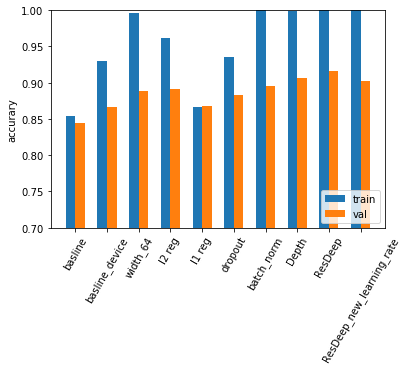

In [33]:
train_data =  [v["train"] for k, v in all_acc_dict.items()]
val_data =  [v["val"] for k, v in all_acc_dict.items()]

width = 0.3
plt.bar(np.arange(len(train_data)), train_data, width=width, label="train")
plt.bar(np.arange(len(val_data))+width, val_data, width=width, label="val")
plt.xticks(np.arange(len(val_data)) + width/2, list(all_acc_dict.keys()), rotation=60)
plt.ylabel("accurary") 
plt.legend(loc="lower right")
plt.ylim(0.7, 1)
plt.savefig("accuracy_comparison.png", bbox_inches="tight")
plt.show()